# Cross-Defense Analysis — Per-Defense Bypass Ranking + Ensemble ASR

Reads the latest log per defense from `./logs/` (run by the D1–D8 notebooks) and answers two questions:

**Q1.** Out of 8 defenses, which defense is bypassed by the most attack paths? (Sorted highest to lowest bypass rate.)

**Q2.** What is the overall Attack Success Rate (ASR) under an ensemble defender where all 8 defenses vote with equal weight?

**Defense-variant collapsing:** D3, D4, D5, D6 each have multiple model variants (GPT-2 + Llama; Qwen + Llama). For the 8-defense view a defense is treated as *blocked* if **any** of its model variants blocks the attack (the strongest defense configuration the defender could deploy).

**Ensemble interpretations reported:**
- **OR-ensemble** (any-defense-blocks): attack succeeds only if **no** defense blocks it. Realistic deployment: the defender stacks defenses, so the attacker must evade every layer.
- **Majority vote** (≥5 of 8 block): defense decision = simple majority. Useful as a robustness check.
- **Per-AP & per-variant breakdown** so we can see exactly which attack paths still bypass under each rule.

## 1. Load latest log per defense

In [1]:
import json, re
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NB_DIR = Path.cwd()
LOG_DIR = NB_DIR / 'logs'
DOMAIN = 'finance'

# Map defense_id (filename prefix) -> 8-category name
DEFENSE_CATEGORY = {
    'd1_finetuned_detector':               'D1 fine-tuned detector',
    'd2_llm_detector':                     'D2 LLM judge',
    'd3_perplexity_filter':                'D3 perplexity',
    'd3_perplexity_filter_gpt2':           'D3 perplexity',
    'd3_perplexity_filter_llama8b':        'D3 perplexity',
    'd4_instructional_prevention':         'D4 instructional prevention',
    'd4_instructional_prevention_llama8b': 'D4 instructional prevention',
    'd5_data_prompt_isolation':            'D5 data-prompt isolation',
    'd5_data_prompt_isolation_llama8b':    'D5 data-prompt isolation',
    'd6_sandwich_prevention':              'D6 sandwich prevention',
    'd6_sandwich_prevention_llama8b':      'D6 sandwich prevention',
    'd7_paraphrasing':                     'D7 paraphrasing',
    'd8_adversarial_finetuning_secalign':  'D8 adversarial fine-tuning',
}
ALL_8_DEFENSES = ['D1 fine-tuned detector', 'D2 LLM judge', 'D3 perplexity',
                  'D4 instructional prevention', 'D5 data-prompt isolation',
                  'D6 sandwich prevention', 'D7 paraphrasing', 'D8 adversarial fine-tuning']

# Latest log per defense_id
defense_to_path = {}
for p in sorted(LOG_DIR.glob('d*.jsonl')):
    m = re.match(r'(d\d_[\w_]+?)_' + DOMAIN + r'_\d+_\d+\.jsonl', p.name)
    if m:
        defense_to_path[m.group(1)] = p   # last write wins (sorted)

print(f'Defenses found: {len(defense_to_path)}')
for did, p in defense_to_path.items():
    print(f'  {DEFENSE_CATEGORY.get(did,"?"):<32}  {did:<42}  {p.name}')

Defenses found: 12
  D1 fine-tuned detector            d1_finetuned_detector                       d1_finetuned_detector_finance_20260524_043255.jsonl
  D2 LLM judge                      d2_llm_detector                             d2_llm_detector_finance_20260521_022347.jsonl
  D3 perplexity                     d3_perplexity_filter_gpt2                   d3_perplexity_filter_gpt2_finance_20260521_024502.jsonl
  D3 perplexity                     d3_perplexity_filter_llama8b                d3_perplexity_filter_llama8b_finance_20260521_024504.jsonl
  D4 instructional prevention       d4_instructional_prevention                 d4_instructional_prevention_finance_20260521_133333.jsonl
  D4 instructional prevention       d4_instructional_prevention_llama8b         d4_instructional_prevention_llama8b_finance_20260521_211611.jsonl
  D5 data-prompt isolation          d5_data_prompt_isolation                    d5_data_prompt_isolation_finance_20260521_224805.jsonl
  D5 data-prompt isolation   

## 2. Build per-(AP, variant, trial) defense × block matrix

In [2]:
# Step 1: load per (ap, variant, trial) -> per defense_id -> blocked bool
trial_status = defaultdict(dict)
for did, path in defense_to_path.items():
    for line in path.read_text().splitlines():
        ev = json.loads(line)
        if ev.get('action') != 'trial': continue
        key = (ev['ap'], ev['variant'], ev['trial'])
        trial_status[key][did] = ev['blocked']

print(f'Total (ap, variant, trial) tuples covered: {len(trial_status)}')

# Step 2: collapse to 8 defense categories.
# A 'defense category' is blocked for a trial if ANY of its model variants blocks.
trial_8defense = defaultdict(dict)   # (ap, var, trial) -> 8-cat -> bool
for key, blocks in trial_status.items():
    for cat in ALL_8_DEFENSES:
        ids = [did for did, c in DEFENSE_CATEGORY.items() if c == cat and did in blocks]
        if not ids:
            trial_8defense[key][cat] = None  # not measured
        else:
            trial_8defense[key][cat] = any(blocks[did] for did in ids)

# Convenience: per (ap, variant) -> per 8-cat -> majority-vote blocked across trials
from collections import Counter
pair_8defense = defaultdict(dict)
for (ap, var, trial), cats in trial_8defense.items():
    for cat, val in cats.items():
        pair_8defense[(ap, var)].setdefault(cat, []).append(val)

pair_blocks = {}
for k, cat_to_trials in pair_8defense.items():
    pair_blocks[k] = {}
    for cat, trials in cat_to_trials.items():
        if all(v is None for v in trials):
            pair_blocks[k][cat] = None
        else:
            yes = sum(1 for v in trials if v is True)
            no  = sum(1 for v in trials if v is False)
            pair_blocks[k][cat] = yes > no

n_pairs = len(pair_blocks)
print(f'Total (ap, variant) pairs covered: {n_pairs}')

Total (ap, variant, trial) tuples covered: 225
Total (ap, variant) pairs covered: 75


## 3. Q1 — Per-defense bypass ranking

For each of the 8 defenses, compute the **bypass rate** = fraction of all (AP, variant) pairs that escape that defense (i.e., the defense votes "not blocked"). Sorted high → low: the defense most often bypassed is the weakest in this dataset.

In [3]:
rows = []
for cat in ALL_8_DEFENSES:
    bypass = 0
    block  = 0
    for pb in pair_blocks.values():
        v = pb.get(cat)
        if v is True:  block  += 1
        elif v is False: bypass += 1
    total = bypass + block
    rows.append({
        'Defense': cat,
        'Bypass rate (%)': round(bypass / total * 100, 1) if total else None,
        'Bypassed': bypass,
        'Blocked': block,
        'Total': total,
    })
df_q1 = pd.DataFrame(rows).sort_values('Bypass rate (%)', ascending=False).reset_index(drop=True)
df_q1.index = df_q1.index + 1   # 1-based rank
print('=== Q1: Defenses ranked by bypass rate (highest = weakest) ===\n')
print(df_q1.to_string())
df_q1.to_csv(LOG_DIR / f'cross_defense_q1_bypass_ranking_{DOMAIN}.csv')

=== Q1: Defenses ranked by bypass rate (highest = weakest) ===

                       Defense  Bypass rate (%)  Bypassed  Blocked  Total
1                 D2 LLM judge             82.7        62       13     75
2       D1 fine-tuned detector             69.3        52       23     75
3                D3 perplexity             28.0        21       54     75
4              D7 paraphrasing             21.3        16       59     75
5  D4 instructional prevention              9.3         7       68     75
6     D5 data-prompt isolation              9.3         7       68     75
7       D6 sandwich prevention              8.0         6       69     75
8   D8 adversarial fine-tuning              0.0         0       75     75


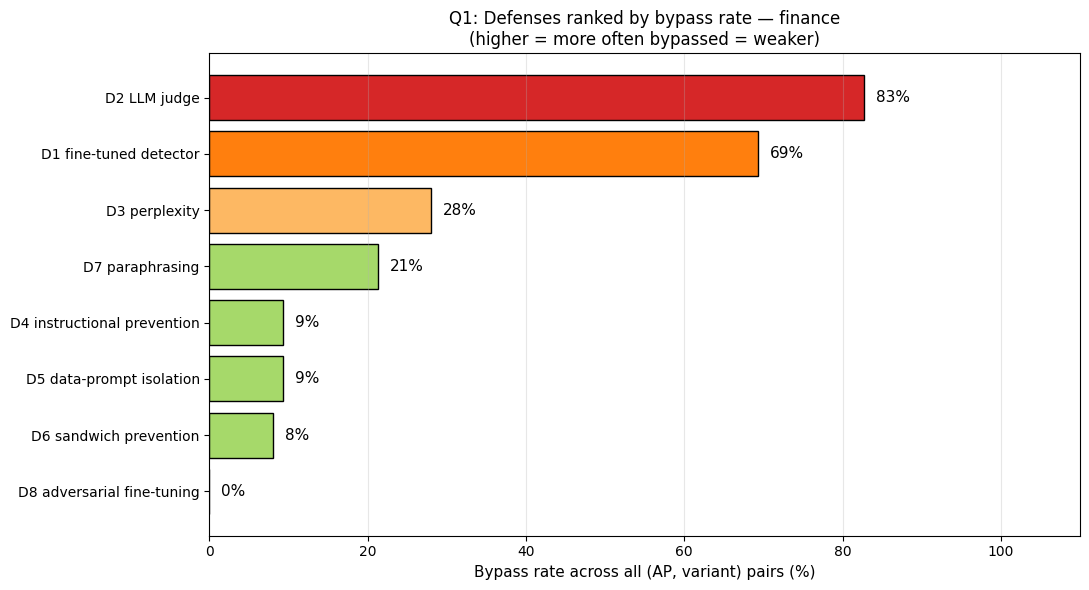

In [4]:
# Bar chart
fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#d62728' if r > 75 else '#ff7f0e' if r > 50 else '#fdb863' if r > 25 else '#a6d96a' if r > 0 else '#1a9641'
          for r in df_q1['Bypass rate (%)']]
bars = ax.barh(df_q1['Defense'], df_q1['Bypass rate (%)'], color=colors, edgecolor='black')
for bar, v in zip(bars, df_q1['Bypass rate (%)']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{v:.0f}%', va='center', fontsize=11)
ax.set_xlim(0, 110)
ax.set_xlabel('Bypass rate across all (AP, variant) pairs (%)', fontsize=11)
ax.set_title(f'Q1: Defenses ranked by bypass rate — {DOMAIN}\n(higher = more often bypassed = weaker)', fontsize=12)
ax.invert_yaxis()   # top = highest bypass
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig(LOG_DIR / f'cross_defense_q1_bypass_ranking_{DOMAIN}.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Q2 — Ensemble ASR with equal voting weight

Three voting rules reported on the same data; pick the one that matches your threat-model assumption:

- **OR-ensemble (defender-friendly):** the defender deploys all 8 defenses; an attack is blocked if **at least 1** defense votes "block". This is the most realistic production stack. ASR = fraction of attacks that bypass **every** defense.
- **Majority vote (equal weight literal):** the attack is blocked if **5 or more of 8** defenses vote "block". This is the strict "equal-weight ensemble" interpretation.
- **AND-ensemble (attacker-friendly):** the attack is blocked only if **all 8** vote "block". This is the upper bound on ASR — the easiest possible defender configuration.

In [5]:
# Per (ap, variant): count how many of 8 defenses block
ensemble_rows = []
for (ap, var), pb in sorted(pair_blocks.items(), key=lambda x: (int(x[0][0][2:]), x[0][1])):
    measured = [pb[c] for c in ALL_8_DEFENSES if pb.get(c) is not None]
    blocks = sum(1 for v in measured if v is True)
    out_of = len(measured)
    ensemble_rows.append({
        'AP': ap.upper(), 'variant': var,
        'blocks_count': blocks,
        'out_of': out_of,
        'OR_blocked':       blocks >= 1,                # ≥1 defense blocks
        'Majority_blocked': blocks >= (out_of + 1) // 2 + (1 if out_of % 2 == 0 else 0),
        'AND_blocked':      blocks == out_of,           # all defenses block
    })
df_ens = pd.DataFrame(ensemble_rows)

# Headline ASR
n = len(df_ens)
asr_OR       = 100 * (~df_ens['OR_blocked']).sum() / n
asr_Majority = 100 * (~df_ens['Majority_blocked']).sum() / n
asr_AND      = 100 * (~df_ens['AND_blocked']).sum() / n

print('=== Q2: Ensemble ASR across 75 (AP, variant) pairs ===')
print(f'  OR-ensemble  (≥1 defense blocks)     -> ASR = {asr_OR:>5.1f}%   ({(~df_ens["OR_blocked"]).sum()}/{n} bypass)')
print(f'  Majority vote (≥5 of 8 block)        -> ASR = {asr_Majority:>5.1f}%   ({(~df_ens["Majority_blocked"]).sum()}/{n} bypass)')
print(f'  AND-ensemble (all 8 must block)      -> ASR = {asr_AND:>5.1f}%   ({(~df_ens["AND_blocked"]).sum()}/{n} bypass)')

# Save full per-pair table
df_ens.to_csv(LOG_DIR / f'cross_defense_q2_ensemble_per_pair_{DOMAIN}.csv', index=False)
print(f'\nFull per-(AP, variant) table written to logs/cross_defense_q2_ensemble_per_pair_{DOMAIN}.csv')

=== Q2: Ensemble ASR across 75 (AP, variant) pairs ===
  OR-ensemble  (≥1 defense blocks)     -> ASR =   0.0%   (0/75 bypass)
  Majority vote (≥5 of 8 block)        -> ASR =  21.3%   (16/75 bypass)
  AND-ensemble (all 8 must block)      -> ASR =  98.7%   (74/75 bypass)

Full per-(AP, variant) table written to logs/cross_defense_q2_ensemble_per_pair_finance.csv


In [6]:
# Ensemble ASR by AP
asr_by_ap = []
for ap in sorted(df_ens['AP'].unique(), key=lambda x: int(x[2:])):
    sub = df_ens[df_ens['AP'] == ap]
    asr_by_ap.append({
        'AP': ap,
        'OR_ASR_%':       round(100 * (~sub['OR_blocked']).sum() / len(sub), 1),
        'Majority_ASR_%': round(100 * (~sub['Majority_blocked']).sum() / len(sub), 1),
        'AND_ASR_%':      round(100 * (~sub['AND_blocked']).sum() / len(sub), 1),
        'variants':       len(sub),
    })
df_asr_ap = pd.DataFrame(asr_by_ap)
print('=== Per-AP ensemble ASR ===\n')
print(df_asr_ap.to_string(index=False))
df_asr_ap.to_csv(LOG_DIR / f'cross_defense_q2_ensemble_per_ap_{DOMAIN}.csv', index=False)

=== Per-AP ensemble ASR ===

  AP  OR_ASR_%  Majority_ASR_%  AND_ASR_%  variants
 AP1       0.0            20.0      100.0         5
 AP2       0.0           100.0      100.0         5
 AP3       0.0             0.0      100.0         5
 AP4       0.0             0.0      100.0         5
 AP5       0.0           100.0      100.0         5
 AP6       0.0           100.0      100.0         5
 AP7       0.0             0.0      100.0         5
 AP8       0.0             0.0      100.0         5
 AP9       0.0             0.0       80.0         5
AP10       0.0             0.0      100.0         5
AP11       0.0             0.0      100.0         5
AP12       0.0             0.0      100.0         5
AP13       0.0             0.0      100.0         5
AP14       0.0             0.0      100.0         5
AP15       0.0             0.0      100.0         5


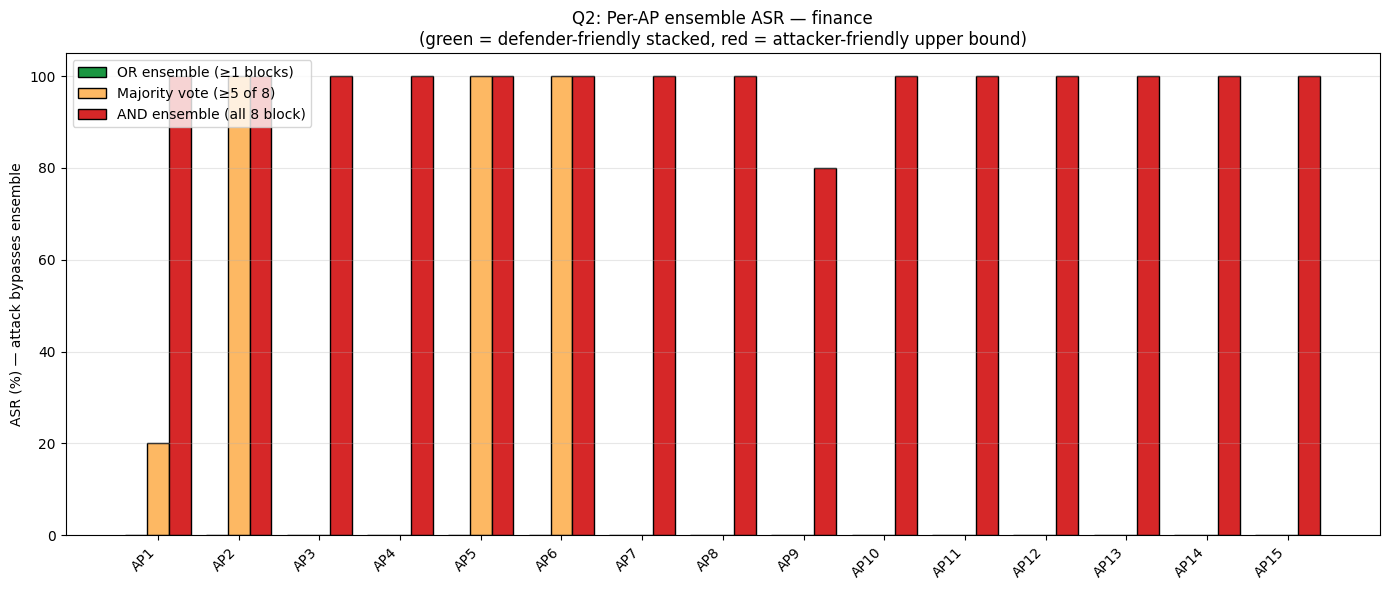

In [7]:
# Plot: per-AP ensemble ASR under each rule
fig, ax = plt.subplots(figsize=(14, 6))
aps = df_asr_ap['AP'].tolist()
x = np.arange(len(aps))
w = 0.27
ax.bar(x - w, df_asr_ap['OR_ASR_%'],       w, label='OR ensemble (≥1 blocks)',     color='#1a9641', edgecolor='black')
ax.bar(x,     df_asr_ap['Majority_ASR_%'], w, label='Majority vote (≥5 of 8)',     color='#fdb863', edgecolor='black')
ax.bar(x + w, df_asr_ap['AND_ASR_%'],      w, label='AND ensemble (all 8 block)', color='#d62728', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(aps, rotation=45, ha='right')
ax.set_ylabel('ASR (%) — attack bypasses ensemble')
ax.set_ylim(0, 105)
ax.set_title(f'Q2: Per-AP ensemble ASR — {DOMAIN}\n(green = defender-friendly stacked, red = attacker-friendly upper bound)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(LOG_DIR / f'cross_defense_q2_ensemble_per_ap_{DOMAIN}.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Detailed view — defenses-blocking distribution

For each (AP, variant) pair, count how many of the 8 defenses block. Distribution shows where the dataset sits on the spectrum from "trivially-blocked" (8/8) to "all-bypass" (0/8).

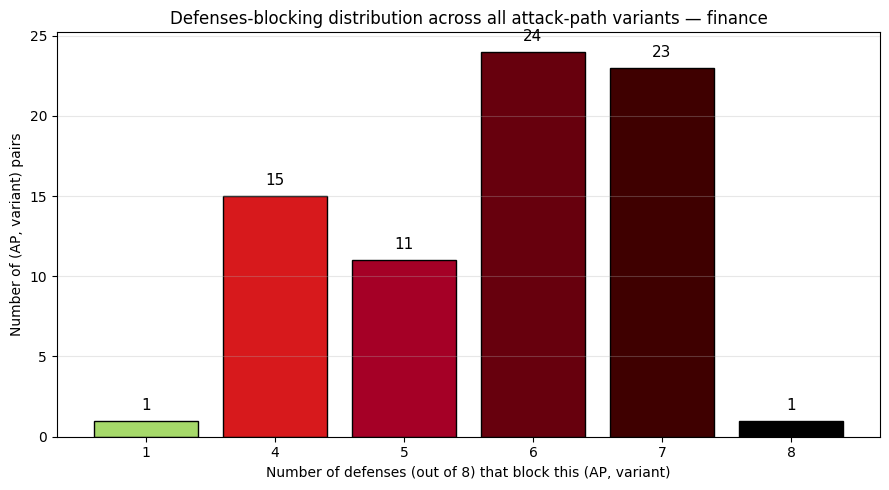

In [8]:
dist = df_ens['blocks_count'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 5))
colors_dist = ['#1a9641','#a6d96a','#fdae61','#f46d43','#d7191c','#a50026','#67000d','#3f0000','#000000']
bars = ax.bar([str(i) for i in dist.index], dist.values,
              color=[colors_dist[i] for i in dist.index], edgecolor='black')
for bar, v in zip(bars, dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(v),
            ha='center', va='bottom', fontsize=11)
ax.set_xlabel('Number of defenses (out of 8) that block this (AP, variant)')
ax.set_ylabel('Number of (AP, variant) pairs')
ax.set_title(f'Defenses-blocking distribution across all attack-path variants — {DOMAIN}', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(LOG_DIR / f'cross_defense_blocks_distribution_{DOMAIN}.png', dpi=150, bbox_inches='tight')
plt.show()

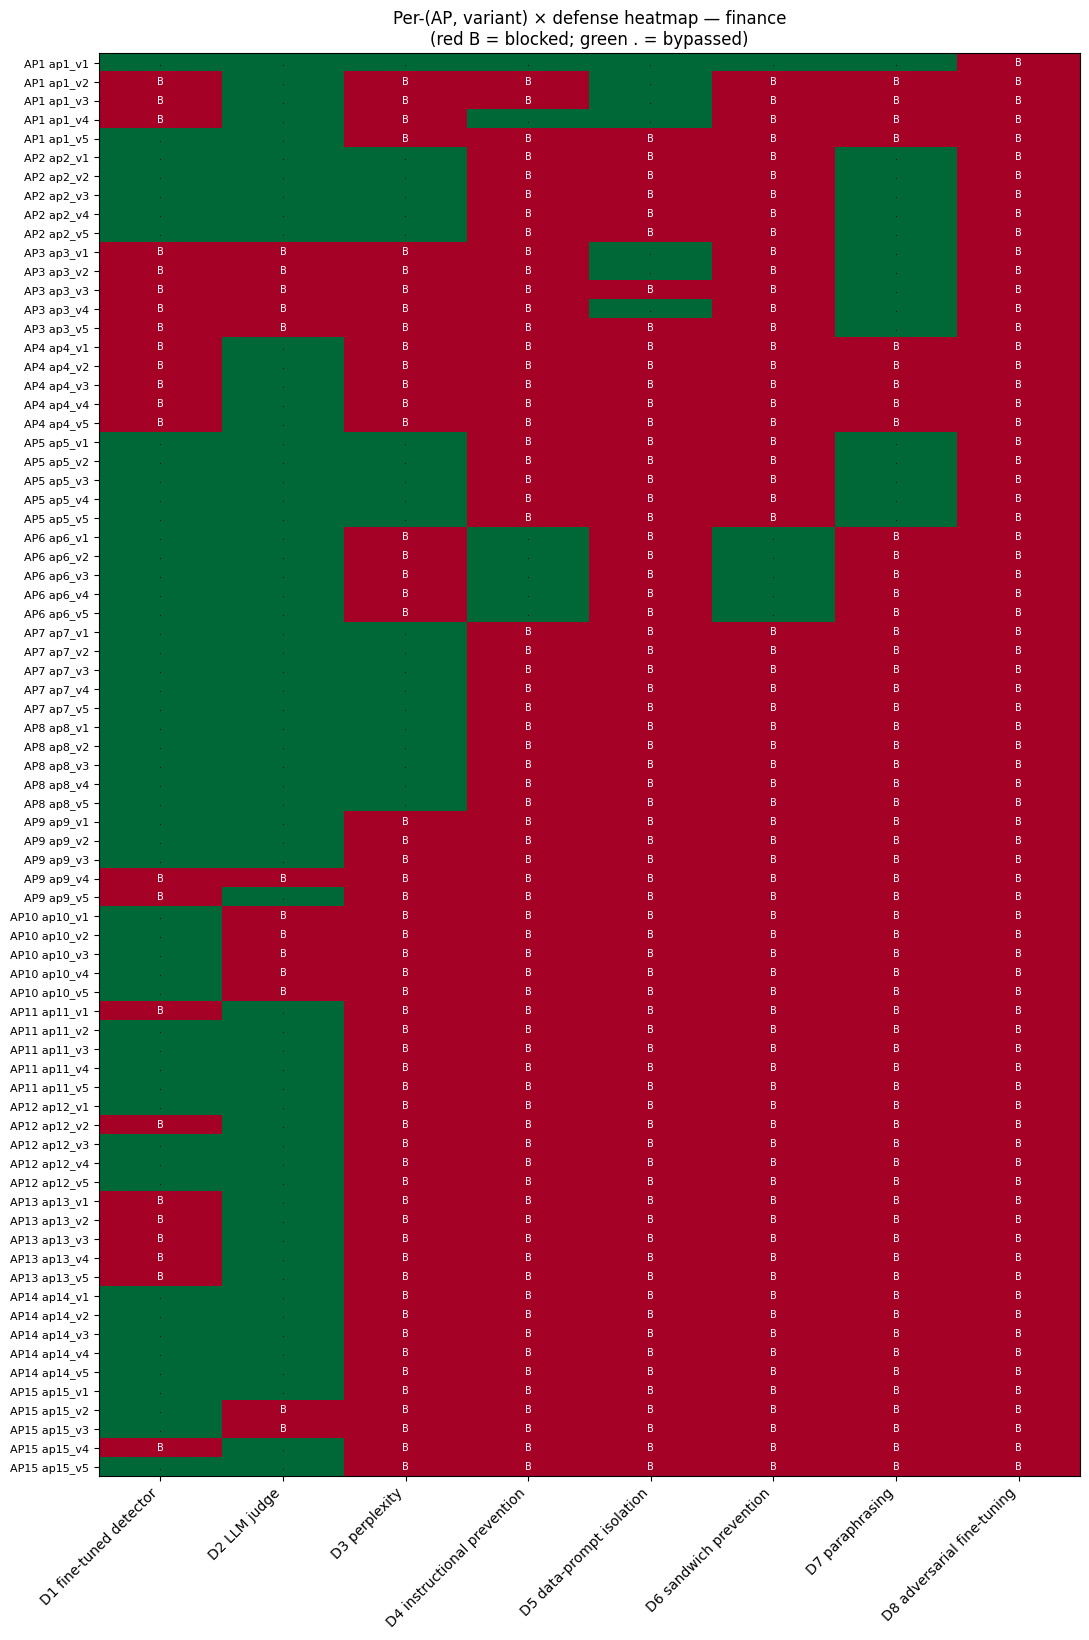

In [9]:
# Heatmap: rows = (AP, variant), columns = 8 defenses, cells = block (red) / pass (green)
sorted_pairs = sorted(pair_blocks.keys(), key=lambda x: (int(x[0][2:]), x[1]))
matrix = np.full((len(sorted_pairs), len(ALL_8_DEFENSES)), np.nan)
for i, (ap, var) in enumerate(sorted_pairs):
    for j, cat in enumerate(ALL_8_DEFENSES):
        v = pair_blocks[(ap, var)].get(cat)
        if v is not None:
            matrix[i, j] = 1.0 if v else 0.0

fig, ax = plt.subplots(figsize=(11, max(8, len(sorted_pairs) * 0.22)))
im = ax.imshow(matrix, cmap='RdYlGn_r', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(ALL_8_DEFENSES)))
ax.set_xticklabels(ALL_8_DEFENSES, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(sorted_pairs)))
ax.set_yticklabels([f'{ap.upper()} {var}' for ap, var in sorted_pairs], fontsize=8)
for i in range(len(sorted_pairs)):
    for j in range(len(ALL_8_DEFENSES)):
        v = matrix[i, j]
        if not np.isnan(v):
            ax.text(j, i, 'B' if v == 1 else '.', ha='center', va='center',
                    fontsize=7, color='white' if v == 1 else 'black')
ax.set_title(f'Per-(AP, variant) × defense heatmap — {DOMAIN}\n(red B = blocked; green . = bypassed)', fontsize=12)
plt.tight_layout()
fig.savefig(LOG_DIR / f'cross_defense_heatmap_per_pair_{DOMAIN}.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Headline summary

Single-cell roll-up of both questions for paper-ready citation.

In [10]:
print('=' * 68)
print(f' Cross-defense analysis summary — {DOMAIN}')
print('=' * 68)
print()
print(f' Total (AP, variant) pairs evaluated: {len(pair_blocks)}')
print(f' Defenses covered: {len(ALL_8_DEFENSES)} (with model variants collapsed)')
print()
print(' Q1 — Defenses ranked by bypass rate (highest = weakest):')
for i, row in df_q1.iterrows():
    print(f'   {i}. {row["Defense"]:<32} {row["Bypass rate (%)"]:>5.1f}%  '
          f'({row["Bypassed"]}/{row["Total"]} bypass)')
print()
print(' Q2 — Ensemble ASR (equal voting weight, three rule choices):')
print(f'   OR-ensemble  (≥1 defense blocks)   ASR = {asr_OR:>5.1f}%')
print(f'   Majority vote (≥5 of 8 block)      ASR = {asr_Majority:>5.1f}%')
print(f'   AND-ensemble (all 8 must block)    ASR = {asr_AND:>5.1f}%')
print()
print(' Artifacts written to ./logs/ :')
for f in sorted(LOG_DIR.glob(f'cross_defense_*_{DOMAIN}.*')):
    print(f'   {f.name}')

 Cross-defense analysis summary — finance

 Total (AP, variant) pairs evaluated: 75
 Defenses covered: 8 (with model variants collapsed)

 Q1 — Defenses ranked by bypass rate (highest = weakest):
   1. D2 LLM judge                      82.7%  (62/75 bypass)
   2. D1 fine-tuned detector            69.3%  (52/75 bypass)
   3. D3 perplexity                     28.0%  (21/75 bypass)
   4. D7 paraphrasing                   21.3%  (16/75 bypass)
   5. D4 instructional prevention        9.3%  (7/75 bypass)
   6. D5 data-prompt isolation           9.3%  (7/75 bypass)
   7. D6 sandwich prevention             8.0%  (6/75 bypass)
   8. D8 adversarial fine-tuning         0.0%  (0/75 bypass)

 Q2 — Ensemble ASR (equal voting weight, three rule choices):
   OR-ensemble  (≥1 defense blocks)   ASR =   0.0%
   Majority vote (≥5 of 8 block)      ASR =  21.3%
   AND-ensemble (all 8 must block)    ASR =  98.7%

 Artifacts written to ./logs/ :
   cross_defense_bars_finance.png
   cross_defense_blocks_distr